In [50]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import matplotlib.pyplot as plt
import numpy as np

from Utils import Notebook, gph, nm, tex

import itertools
import numpy as np
import cvxpy as cp
from typing import Dict, Any 
import matplotlib as mpl
from scipy.stats import skew
import math

from Engine import *

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

mpl.rcParams['figure.dpi'] = 75

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


LaTeX has been enabled for text rendering.


### Definição da Planta

In [12]:
simulator = Engine()
simulator.load_lpv_model("../../data/sys-02.json")

# Inspeção dinâmica dos estados (acessando via 'lpv_model')
print("Estados do Sistema:")
for state_name, info in simulator.lpv_model['states'].items():
  print(f"- {state_name}: {info['name']} (Símbolo: {info['symbol']})")

# Inspeção dinâmica dos parâmetros
print("\nParâmetros:")
for param_name, info in simulator.lpv_model['parameters'].items():
  print(f"- {param_name}: Valor definido como '{info['value']}'")

# Acesso direto à matriz A (via 'lpv_model')
matrix_a = simulator.lpv_model['system_matrices']['A']
print(f"\nMatriz A:\n{matrix_a}")

Estados do Sistema:
- x1: Posição Angular (Símbolo: $x_1$)
- x2: Velocidade Angular (Símbolo: $x_2$)

Parâmetros:
- p1: Valor definido como '.5 * cos(t)'

Matriz A:
[['0.0', '1.0'], ['0.1', '0.4 + 0.6 * p1']]


### Simulação da Planta em Malha Aberta

In [13]:
%%skip

# Definição dinâmica da condição inicial
x0 = np.array([1.0, -1.0], dtype=np.float64)
simulator.set_initial_state(x0)

# Simulação unificada: configura e executa em malha aberta
# Retorna (time, states) onde states está no formato [n_steps, n_states]
time, states = simulator.run_open_loop_simulation(
    sample_time=1e-4, duration=20.0)

# Transposição para alinhar com o formato esperado de [n_states, n_time_steps]
states = states.T

Cell skipped (unconditional).


In [14]:
%%skip

fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], time, [states[0], states[1]],
    label=[r'$x_1(t)$', r'$x_2(t)$'],
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=fr'$x$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

Cell skipped (unconditional).


### Projeto do Controlador e do ETM

In [15]:
import itertools
from dataclasses import dataclass
from typing import Dict, Any, Tuple, List
import cvxpy as cp
import numpy as np


@dataclass
class ProblemData:
  nx: int
  nu: int
  nρ: int
  h: float
  υ: float
  λ: float
  A: Dict[Tuple[int, ...], cp.Parameter]
  B: Dict[Tuple[int, ...], cp.Parameter]
  e: List[Any]
  dtype: Any


@dataclass
class DecisionVariables:
  Ptil: cp.Variable
  Mtil: cp.Variable
  Q1til: cp.Variable
  Q2til: cp.Variable
  Q3til: cp.Variable
  S1til: cp.Variable
  S2til: cp.Variable
  S3til: cp.Variable
  Ktil: cp.Variable
  Rtil: cp.Variable
  Ξtil: cp.Variable
  Ψtil: cp.Variable
  X: cp.Variable
  Ytil: cp.Variable


@dataclass
class Constants:
  Onx: np.ndarray
  exp_λh: float
  Rcal: cp.Expression
  Fscr: Any
  κ1: cp.Expression
  κ2: cp.Expression
  Λ1: cp.Expression
  Λ2: cp.Expression
  Λ3: cp.Expression


def control_synthesis(
    design_params: Dict[str, float],
    eps: float = 1e-6,
    dtype=np.float32
) -> Dict[str, Any]:

  def _create_problem_data() -> ProblemData:
    model = simulator.lpv_model
    _nx = len(model['states'])
    _nu = len(model['inputs'])
    _nρ = len(model['parameters'])
    ρ_bounds = [param['bounds'] for param in model['parameters'].values()]

    _h = design_params['h']
    _υ = design_params['υ']
    _λ = design_params['λ']

    Bnp = list(itertools.product([0, 1], repeat=_nρ))

    _A, _B = {}, {}
    param_names = list(model['parameters'].keys())
    for i in Bnp:
      rho_dict = {param_names[idx]: ρ_bounds[idx][i[idx]]
                  for idx in range(_nρ)}
      mat_A = simulator.get_matrix("A", rho_dict)
      mat_B = simulator.get_matrix("B", rho_dict)
      _A[i] = cp.Parameter((_nx, _nx), value=mat_A.astype(dtype))
      _B[i] = cp.Parameter((_nx, _nu), value=mat_B.astype(dtype))

    _e = nm.get_e(5 * [_nx])
    for idx in range(1, len(_e)):
      _e[idx] = cp.Parameter(_e[idx].shape, value=_e[idx].astype(dtype))

    return ProblemData(
        nx=_nx, nu=_nu, nρ=_nρ, h=_h, υ=_υ, λ=_λ,
        A=_A, B=_B, e=_e, dtype=dtype
    )

  def _create_variables() -> DecisionVariables:
    nx = data.nx
    nu = data.nu
    e_shape_1 = data.e[1].shape[1]

    return DecisionVariables(
        Ptil=cp.Variable((nx, nx), PSD=True),
        Mtil=cp.Variable((2*nx, 2*nx), PSD=True),
        Q1til=cp.Variable((nx, nx), symmetric=True),
        Q2til=cp.Variable((nx, nx)),
        Q3til=cp.Variable((nx, nx)),
        S1til=cp.Variable((nx, nx), symmetric=True),
        S2til=cp.Variable((nx, nx)),
        S3til=cp.Variable((nx, nx)),
        Ktil=cp.Variable((nu, nx)),
        Rtil=cp.Variable((nx, nx), PSD=True),
        Ξtil=cp.Variable((nx, nx), PSD=True),
        Ψtil=cp.Variable((nx, nx), PSD=True),
        X=cp.Variable((nx, nx)),
        Ytil=cp.Variable((2*nx, e_shape_1))
    )

  def _build_constants() -> Constants:
    nx = data.nx
    e = data.e
    υ = data.υ
    λ = data.λ
    h = data.h

    _Onx = np.zeros((nx, nx), dtype=data.dtype)
    _exp_λh = np.exp(- 2. * λ * h)
    _Rcal = cp.bmat([[vars.Rtil, _Onx], [_Onx, 3. * vars.Rtil]])
    _Fscr = e[1].T + υ * e[2].T + υ * e[4].T
    _κ1 = cp.bmat([[e[2]], [e[5]]])
    _κ2 = cp.bmat([[e[1] - e[2]], [e[1] + e[2] - 2. * e[3]]])

    _Λ1 = (e[1] - e[2]).T @ vars.S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (vars.S2til @
              e[2] + vars.S3til @ e[5]))

    _Λ2 = _κ1.T @ vars.Mtil @ _κ1 - e[4].T @ vars.Rtil @ e[4] - e[3].T @ vars.Q1til @ e[3] + \
        nm.He((e[1] - e[2]).T @ vars.S1til @ e[4] + e[4].T @ vars.S2til @ e[2] +
              e[4].T @ vars.S3til @ e[5] + e[1].T @ vars.Q1til @ e[3] +
              e[1].T @ vars.Q2til @ e[2] + e[1].T @ vars.Q3til @ e[5])

    _Λ3 = e[3].T @ vars.Q1til @ e[3] + _κ1.T @ vars.Mtil @ _κ1 + \
        nm.He(e[3].T @ (vars.Q2til @ e[2] + vars.Q3til @ e[5]))

    return Constants(
        Onx=_Onx, exp_λh=_exp_λh, Rcal=_Rcal, Fscr=_Fscr,
        κ1=_κ1, κ2=_κ2, Λ1=_Λ1, Λ2=_Λ2, Λ3=_Λ3
    )

  def _theta0(i: Tuple[int, ...]) -> cp.Expression:
    e = data.e
    Bscr = data.A[i] @ vars.X @ e[1] + data.B[i] @ vars.Ktil @ e[2] + \
        data.B[i] @ vars.Ktil @ e[5] - vars.X @ e[4]
    return - e[5].T @ vars.Ξtil @ e[5] - 2. * data.λ * consts.exp_λh * consts.Λ1 + \
        (1. - consts.exp_λh) * consts.Λ2 + \
        nm.He(consts.Fscr @ Bscr + e[1].T @ vars.Ptil @ e[4] + data.λ * e[1].T @ vars.Ptil @ e[1] +
              2. * data.λ * consts.exp_λh * consts.κ2.T @ vars.Ytil)

  def _thetah(i: Tuple[int, ...]) -> cp.Expression:
    e = data.e
    Bscr = data.A[i] @ vars.X @ e[1] + data.B[i] @ vars.Ktil @ e[2] + \
        data.B[i] @ vars.Ktil @ e[5] - vars.X @ e[4]
    return - e[5].T @ vars.Ξtil @ e[5] - 2. * data.λ * consts.exp_λh * \
        (consts.Λ1 + data.h * consts.Λ3 - nm.He(consts.κ2.T @ vars.Ytil)) + \
        nm.He(consts.Fscr @ Bscr + e[1].T @ vars.Ptil @
              e[4] + data.λ * e[1].T @ vars.Ptil @ e[1])

  def _gamma(i: Tuple[int, ...]) -> Tuple[cp.Expression, cp.Expression]:
    e = data.e
    nx = data.nx

    Γ1_11 = _theta0(i)
    Γ1_12 = e[2].T @ vars.X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - vars.Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = _thetah(i)
    Γ2_12 = vars.Ytil.T
    Γ2_13 = e[2].T @ vars.X.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (np.exp(2. * data.λ * data.h) /
               (2. * data.λ * data.h)) * consts.Rcal
    Γ2_23 = np.zeros((2 * nx, nx))

    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - vars.Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  def _recover_solution() -> Dict[str, Any]:
    if problem.status in ["infeasible", "unbounded"]:
      return None

    nx = data.nx
    dt = data.dtype

    X_val = vars.X.value.astype(dt)
    Xinv = np.linalg.inv(X_val)
    XinvT = Xinv.T

    Xinv_2x = np.block([[Xinv, np.zeros((nx, nx), dtype=dt)],
                        [np.zeros((nx, nx), dtype=dt), Xinv]])
    XinvT_2x = Xinv_2x.T

    Ξ = XinvT @ vars.Ξtil.value.astype(dt) @ Xinv
    Ψ = np.linalg.inv(vars.Ψtil.value.astype(dt))
    K = vars.Ktil.value.astype(dt) @ Xinv

    P = XinvT @ vars.Ptil.value.astype(dt) @ Xinv
    R = XinvT @ vars.Rtil.value.astype(dt) @ Xinv

    S1 = XinvT @ vars.S1til.value.astype(dt) @ Xinv
    S2 = XinvT @ vars.S2til.value.astype(dt) @ Xinv
    S3 = XinvT @ vars.S3til.value.astype(dt) @ Xinv

    Q1 = XinvT @ vars.Q1til.value.astype(dt) @ Xinv
    Q2 = XinvT @ vars.Q2til.value.astype(dt) @ Xinv
    Q3 = XinvT @ vars.Q3til.value.astype(dt) @ Xinv

    M = XinvT_2x @ vars.Mtil.value.astype(dt) @ Xinv_2x
    Y = XinvT_2x @ vars.Ytil.value.astype(dt)

    return {
        'optimal_value': problem.value,
        'etm': {'Ξ': Ξ, 'Ψ': Ψ},
        'controller': {'K': K},
        'functional': {
            'P': P, 'R': R, 'M': M,
            'S1': S1, 'S2': S2, 'S3': S3,
            'Q1': Q1, 'Q2': Q2, 'Q3': Q3,
            'Y': Y
        },
    }

  data = _create_problem_data()
  vars = _create_variables()
  consts = _build_constants()

  constraints = []

  for i in nm.binary_set(data.nρ):
    Λ0, Λh = _gamma(i)
    constraints += [Λ0 << -eps * np.eye(Λ0.shape[0], dtype=dtype)]
    constraints += [Λh << -eps * np.eye(Λh.shape[0], dtype=dtype)]

  constraints += [vars.Ψtil >> eps * np.eye(data.nx, dtype=dtype)]
  constraints += [vars.Ξtil >> eps * np.eye(data.nx, dtype=dtype)]

  obj = cp.Minimize(cp.trace(vars.Ξtil + vars.Ψtil))
  problem = cp.Problem(obj, constraints)
  problem.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

  return _recover_solution()

In [16]:
Ξ = Ψ = K = L1 = P = γ = β = None
optimal_value = None
design_params = {'h': 0.1, 'υ': 0.1, 'λ': 0.1}

results = control_synthesis(design_params)

Ξ, Ψ = results['etm']['Ξ'], results['etm']['Ψ']
K = results['controller']['K']
# P, S2 = results['functional']
optimal_value = results['optimal_value']

display(Math(rf'\Xi = {tex.mat2tex(Ξ)}'))
display(Math(rf'\Psi = {tex.mat2tex(Ψ)}'))
# display(Math(rf'P = {tex.mat2tex(P)}'))
display(Math(rf'K = {tex.mat2tex(K)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [17]:
batch_results = simulator.run_closed_loop_simulation(
    x0_list=[np.array([1.0, -1.0], dtype=np.float64),
             np.array([-1.0, 1.0], dtype=np.float64)],
    K_list=[K] * 2,
    Xi_list=[Ξ] * 2,
    Psi_list=[Ψ] * 2,
    sampling_period=0.1,
    sample_time=0.0001,
    duration=20.0
)

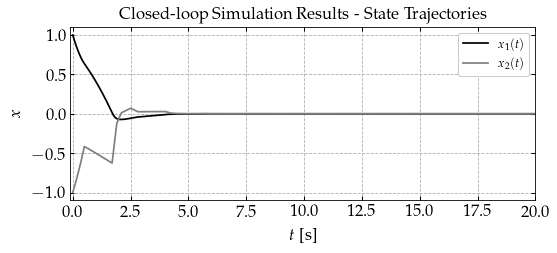

In [33]:
idx = 0
time = batch_results[idx]['time']
states = batch_results[idx]['states'].T

fig, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs['x'], time, [states[0], states[1]],
    label=[r'$x_1(t)$', r'$x_2(t)$'],
    title='Closed-loop Simulation Results - State Trajectories',
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=fr'$x$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

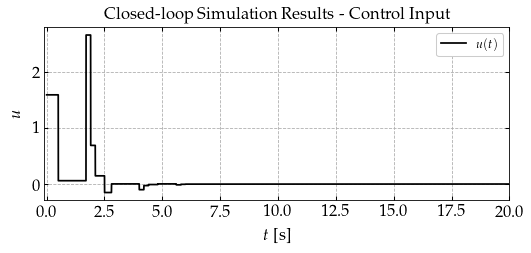

In [38]:
signal_control = batch_results[idx]['control']

fig, axs = plt.subplot_mosaic([['u']], figsize=(8, 3))
_ = gph.plot(
    axs['u'], time, signal_control,
    label=[r'$u(t)$'], xlabel='$t$',
    x_unit='s', x_use_prefixes=True,
    title='Closed-loop Simulation Results - Control Input',
    ylabel=fr'$u$', color=['black', 'gray'],
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

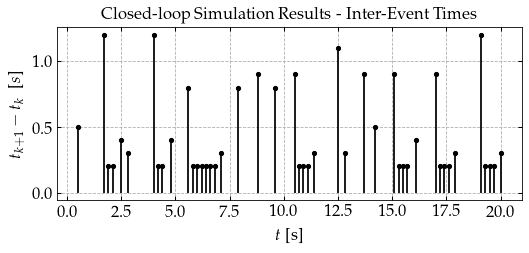

In [46]:
events = batch_results[idx]['events']
iet = np.diff(events)

fig, axs = plt.subplot_mosaic([['iet']], figsize=(8, 3))
_ = gph.stem(
    axs['iet'], events[1:], iet, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, time[-1]),
    title='Closed-loop Simulation Results - Inter-Event Times',
    ylabel='$t_{k+1} - t_k\\;$ [$s$]',
    cfg={'limits': {'x_min': 0, 'x_max': time[-1]},
         'style': {'color': "black"}})

In [58]:
def _create_embedding_matrix(x, order):
  """Cria matriz de embutimento para entropia."""
  n = len(x) - order + 1
  return np.array([x[i:i + order] for i in range(n)])


def calculate_sampen(iet, order=2, r=0.2):
  """Calcula a Sample Entropy manualmente."""
  iet = np.array(iet)
  std = np.std(iet)
  tolerance = r * std

  def count_matches(m):
    phi = _create_embedding_matrix(iet, m)
    dist = np.max(np.abs(phi[:, np.newaxis] - phi), axis=2)
    return np.sum(dist < tolerance) - len(phi)

  return -np.log(count_matches(order + 1) / count_matches(order))


def calculate_apen(iet, order=2, r=0.2):
  """Calcula a Approximate Entropy manualmente."""
  iet = np.array(iet)
  std = np.std(iet)
  tolerance = r * std

  def phi(m):
    mat = _create_embedding_matrix(iet, m)
    dist = np.max(np.abs(mat[:, np.newaxis] - mat), axis=2)
    return np.sum(np.log(np.sum(dist < tolerance, axis=1) / len(mat))) / len(mat)

  return phi(order) - phi(order + 1)


def calculate_pe(iet, order=3):
  """Calcula a Permutation Entropy manualmente."""
  n = len(iet)
  # Gera as permutações ordinais
  sorted_idx = np.array([np.argsort(iet[i:i + order])
                        for i in range(n - order + 1)])

  # Conta a frequência de cada padrão
  _, counts = np.unique(sorted_idx, axis=0, return_counts=True)
  probs = counts / len(sorted_idx)

  # Cálculo da entropia: usa math.factorial para evitar o erro de atributo do numpy
  return -np.sum(probs * np.log(probs)) / math.log(math.factorial(order))


def analyze_iet_sequence(iet_sequence):
  """Analisa a sequência de IETs sem dependência da biblioteca antropy."""
  iet = np.array(iet_sequence)
  if len(iet) < 10:  # Entropias exigem amostras mínimas
    return "Sequência muito curta para análise."

  # Métricas Estatísticas
  mean_iet = np.mean(iet)
  std_iet = np.std(iet, ddof=1)

  results = {
      "num_transmissions": len(iet),
      "min": np.min(iet),
      "max": np.max(iet),
      "mean": mean_iet,
      "std": std_iet,
      "cv": std_iet / mean_iet if mean_iet != 0 else 0,
      "avg_rate": 1.0 / mean_iet,
      "skewness": skew(iet),
      # Entropias sem dependência externa
      "apen": calculate_apen(iet),
      "sampen": calculate_sampen(iet),
      "pe": calculate_pe(iet)
  }
  return results


def print_iet_analysis(results):
  """Exibe o dicionário de resultados de forma organizada."""
  if isinstance(results, str):
    print(results)
    return

  print(f"{'='*45}")
  print(f"{'ANÁLISE DE INTERVALOS ENTRE EVENTOS (IET)':^45}")
  print(f"{'='*45}")

  print(f"{'MÉTRICAS ESTATÍSTICAS':<30}")
  print(f"{'- Número de Transmissões:':<30} {results['num_transmissions']}")
  print(f"{'- Média (Mean):':<30} {results['mean']:.6f} s")
  print(f"{'- Desvio Padrão (Std):':<30} {results['std']:.6f} s")
  print(f"{'- Coef. de Variação (CV):':<30} {results['cv']:.4f}")
  print(f"{'- Mínimo:':<30} {results['min']:.6f} s")
  print(f"{'- Máximo:':<30} {results['max']:.6f} s")
  print(f"{'- Taxa Média (Rate):':<30} {results['avg_rate']:.2f} Hz")
  print(f"{'- Assimetria (Skewness):':<30} {results['skewness']:.4f}")

  print(f"\n{'MÉTRICAS DE CAOS / ENTROPIA':<30}")
  print(f"{'- Entropia Aprox (ApEn):':<30} {results['apen']:.4f}")
  print(f"{'- Sample Entropy (SampEn):':<30} {results['sampen']:.4f}")
  print(f"{'- Permutation Ent. (PE):':<30} {results['pe']:.4f}")
  print(f"{'='*45}")

In [59]:
analysis_results = analyze_iet_sequence(iet)
print_iet_analysis(analysis_results)

  ANÁLISE DE INTERVALOS ENTRE EVENTOS (IET)  
MÉTRICAS ESTATÍSTICAS         
- Número de Transmissões:      45
- Média (Mean):                0.444444 s
- Desvio Padrão (Std):         0.337474 s
- Coef. de Variação (CV):      0.7593
- Mínimo:                      0.200000 s
- Máximo:                      1.200000 s
- Taxa Média (Rate):           2.25 Hz
- Assimetria (Skewness):       1.1027

MÉTRICAS DE CAOS / ENTROPIA   
- Entropia Aprox (ApEn):       0.5360
- Sample Entropy (SampEn):     1.0198
- Permutation Ent. (PE):       0.7619
